# ETFs: Feasibility Analysis

`config/setup.yaml` declares a long-only cross-sectional ETF rotation: which funds are in scope,
how often the book turns over, what crossing costs, how the sample is split. This notebook asks
whether the data supports it, and fits nothing.

## Learning objectives

- Build point-in-time universe membership, and count it on the dates the strategy acts on
- Price the round trip per fund, and read clearance off an exceedance curve scaled by it
- Measure how long the return a rotation ranks on persists, and fit the declared folds cleanly

## Book reference

Chapter 6, Sections 6.2-6.6. Reads the ETF price panel and `config/setup.yaml`.

In [1]:
"""ETF Case Study - Feasibility Analysis."""

import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_etfs
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
START_DATE = "2006-01-01"
END_DATE = "2025-12-31"
ADV_THRESHOLD = 10e6

## Configuration

Every knob comes from `setup.yaml`, and Section B computes on the development window alone, so
nothing the holdout contains can shape a choice made here. `universe.eligibility_rule` declares
the rule without its number, so the dollar-volume floor is declared in the parameters cell.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
DECLARED_ASSETS = set(SETUP["universe"]["assets"])
BREADTH_FLOOR = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
PER_SHARE = SETUP["costs"]["per_share"]
HALF_SPREADS = SETUP["costs"]["asset_spreads"]
DEFAULT_HALF_SPREAD = SETUP["costs"]["default_half_spread_usd"]
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]
HORIZONS = sorted(int(re.search(r"(\d+)d$", n).group(1)) for n in LABELS)
PRIMARY_HORIZON = int(re.search(r"(\d+)d$", PRIMARY_LABEL).group(1))

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"{len(DECLARED_ASSETS)} declared, floor {BREADTH_FLOOR} | horizons {HORIZONS} sessions")

Development 2006-01-01 to 2024-01-01 | sealed holdout to 2025-12-31
100 declared, floor 20 | horizons [5, 21] sessions


## A. Orientation

Exchange-traded funds package equity, credit, sovereign, currency and commodity exposure into
instruments that settle like shares, so one account rebalances an allocation across asset classes
with ordinary orders. Ranking those funds and holding the leaders trades the difference between
their recent paths rather than a view on any one market, so it needs many quoting at once more than
a few quoting well. Three questions decide whether that is worth building here: does the universe
exist on every decision date, is a typical move large next to what it costs to capture, and are
there enough decision dates for a clean walk-forward.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe

The loader returns one row per fund and session, with `close` adjusted for splits and distributions,
so its differences are returns rather than corporate actions. Two properties hold before anything is
computed from it: nothing outside `universe.assets`, and no close at or below zero.

In [4]:
prices = (
    load_etfs(start_date=START_DATE, end_date=END_DATE)
    .select(["symbol", "timestamp", "close", "volume"])
    .sort(["symbol", "timestamp"])
)
research = prices.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date())

undeclared = sorted(set(research["symbol"].unique().to_list()) - DECLARED_ASSETS)
assert not undeclared, f"loaded but absent from setup.yaml::universe.assets: {undeclared}"
assert research["close"].min() > 0, "a non-positive close is not a denominator"
print(
    f"{research['symbol'].n_unique()} funds, {len(research):,} rows to {research['timestamp'].max()}"
)

100 funds, 420,462 rows to 2023-12-29


### B.2 Breadth at every decision date

`universe.eligibility_rule` admits a fund to a year when its average daily dollar volume over the
*previous* year cleared the floor, so membership is decided by what the strategy already knew.
Selecting on whole-sample volume would instead keep exactly the funds that stayed liquid.

In [5]:
eligibility = (
    prices.with_columns(
        dollar_volume=pl.col("close") * pl.col("volume"), year=pl.col("timestamp").dt.year()
    )
    .group_by(["symbol", "year"])
    .agg(pl.col("dollar_volume").mean().alias("adv"), pl.len().alias("n_days"))
    # a fund quoting for part of a year has no annual average to be admitted on
    .filter((pl.col("n_days") >= 200) & (pl.col("adv") >= ADV_THRESHOLD))
    .select("symbol", (pl.col("year") + 1).alias("eligible_year"))
    .unique()
    .sort(["symbol", "eligible_year"])
)

One count of the universe hides what a cross-sectional rotation has to answer: whether enough funds
are eligible *on the session it acts on*, against the largest position count the sweep asks for.

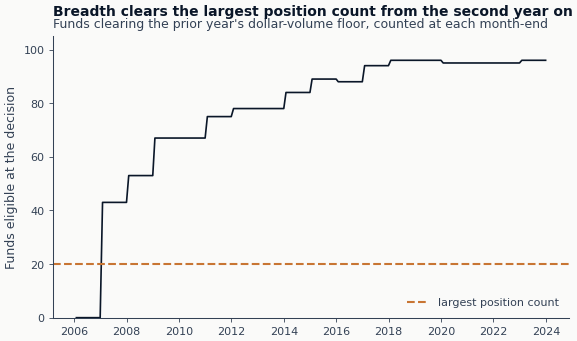

In [6]:
month_end = research.filter(
    pl.col("timestamp") == pl.col("timestamp").max().over(pl.col("timestamp").dt.truncate("1mo"))
)
eligible = eligibility.rename({"eligible_year": "year"}).with_columns(eligible=pl.lit(True))
breadth = (
    month_end.with_columns(year=pl.col("timestamp").dt.year())
    # a left join keeps the dates on which nothing is eligible, which an inner join drops
    .join(eligible, ["symbol", "year"], how="left")
    .group_by("timestamp")
    .agg(pl.col("eligible").fill_null(False).sum().alias("n_eligible"))
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_eligible"], color=COLORS["blue"], linewidth=1.2)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="largest position count")
ax.set_ylim(0, len(DECLARED_ASSETS) + 5)
ax.set_ylabel("Funds eligible at the decision")
ax.legend(frameon=False, fontsize=8, loc="lower right")
add_message_title(
    ax,
    "Breadth clears the largest position count from the second year on",
    subtitle="Funds clearing the prior year's dollar-volume floor, counted at each month-end",
)
plt.show()

### B.3 What the round trip costs, and what a move is worth

`setup.yaml::costs` prices a trade as a per-share commission plus a half-spread assigned by
liquidity tier: daily bars carry no bid and ask, so the spread is asserted rather than measured,
and `16_costs` stresses that assumption. Both are dollars per share, so what they cost
as a fraction of the position falls as a fund's price rises; the chart takes each at its median.

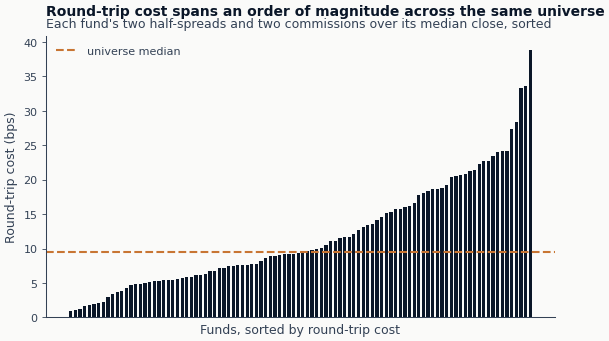

In [7]:
half_spread = pl.col("symbol").replace_strict(
    HALF_SPREADS, default=DEFAULT_HALF_SPREAD, return_dtype=pl.Float64
)
cost = (
    research.group_by("symbol")
    .agg(pl.col("close").median().alias("price"))
    .with_columns((2 * (half_spread + PER_SHARE) / pl.col("price") * 1e4).alias("cost_bps"))
    .sort("cost_bps")
)
COST_BPS = float(cost["cost_bps"].median())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.bar(cost["symbol"], cost["cost_bps"], color=COLORS["blue"], width=0.7)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="universe median")
ax.set_ylabel("Round-trip cost (bps)")
ax.set_xlabel("Funds, sorted by round-trip cost")
ax.set_xticks([])  # a hundred tickers are unreadable, and the spread of the curve is the point
ax.legend(frameon=False, fontsize=8)
add_message_title(
    ax,
    "Round-trip cost spans an order of magnitude across the same universe",
    subtitle="Each fund's two half-spreads and two commissions over its median close, sorted",
)
plt.show()

One cost line on raw returns answers the question for no fund in particular. Each move is divided
instead by what its own fund charged at the price the position opened at, which puts break-even at
one on a scale they all share. The curve runs over every session in the development window, not
only the dates the strategy acts on: it is the scale of a move against cost, not an opportunity set.

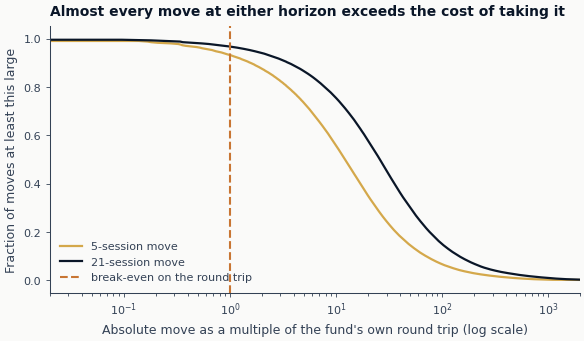

In [8]:
returns = research.with_columns(
    cost_bps=2 * (half_spread + PER_SHARE) / pl.col("close") * 1e4
).with_columns(
    (pl.col("close").pct_change(h).abs() * 1e4 / pl.col("cost_bps").shift(h))
    .over("symbol")
    .alias(f"h{h}")
    for h in HORIZONS
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["amber"], COLORS["blue"]), strict=True):
    multiple, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(multiple, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(1, color=COLORS["copper"], ls="--", lw=1.5, label="break-even on the round trip")
ax.set_xscale("log")
ax.set_xlim(0.02, 2_000)
ax.set_xlabel("Absolute move as a multiple of the fund's own round trip (log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(ax, "Almost every move at either horizon exceeds the cost of taking it")
plt.show()

### B.4 Serial correlation of the carrier

The carrier is what the ranking is built from: the return between consecutive decision dates. Its
serial correlation inside each fund says how much of one month's return the next repeats, a
property of that series and not of the cross-sectional ranking, which `05_evaluation` measures.
Stacking a hundred funds and correlating the result would measure their joins instead.

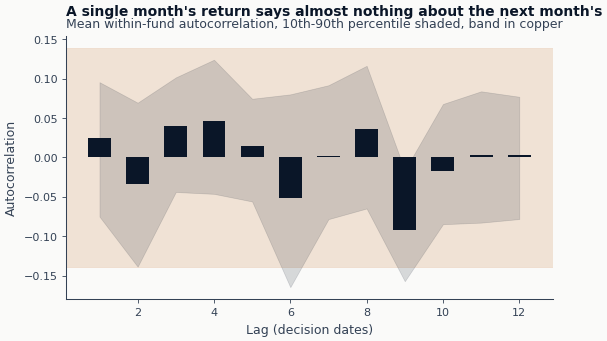

In [9]:
monthly = month_end.with_columns(monthly_return=pl.col("close").pct_change().over("symbol"))
# lag zero is a series against itself, and its bar would flatten every other one
acf = panel_acf(monthly, entity_col="symbol", value_col="monthly_return", max_lags=12).filter(
    pl.col("lag") > 0
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.18, zorder=0)
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6)
ax.set_xlabel("Lag (decision dates)")
ax.set_ylabel("Autocorrelation")
add_message_title(
    ax,
    "A single month's return says almost nothing about the next month's",
    subtitle="Mean within-fund autocorrelation, 10th-90th percentile shaded, band in copper",
)
plt.show()

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the median round trip; the
clearance share counts moves above what their own fund charged. Both are unsigned magnitudes, so
neither says a strategy earns anything - only that cost is not what would stop one.

In [10]:
moves = returns.select(
    move_bps=1e4 * pl.col("close").pct_change(PRIMARY_HORIZON).abs().over("symbol"),
    clears=pl.col(f"h{PRIMARY_HORIZON}") > 1,
)
print(
    f"Round-trip cost {cost['cost_bps'].min():.2f} to {cost['cost_bps'].max():.2f} bps, median "
    f"{COST_BPS:.2f} bps | median {PRIMARY_HORIZON}-session move "
    f"{moves['move_bps'].median():.1f} bps, ratio {moves['move_bps'].median() / COST_BPS:.0f}x, "
    f"over its own fund's cost {moves['clears'].mean():.3f}"
)

Round-trip cost 0.90 to 38.91 bps, median 9.45 bps | median 21-session move 287.2 bps, ratio 30x, over its own fund's cost 0.967


The round trip costs 0.90 to 38.91 bps at each fund's median close, a universe median of 9.45. The
median absolute 21-session move is 287.2 bps, 30x that, and 0.967 of moves clear their entry cost.

## C. Design decisions

### C.1 Cadence. `setup.yaml::decision.cadence` ranks funds at the month-end close and executes at
the next open. B.3 supports rebalancing that often, since moves at both declared horizons clear
the round trip their own fund charges. A month also buys a purge gap the width of the primary
label, and the weekly horizon stays in `labels.variants` so the shorter holding period is measured.

### C.2 Kill conditions. Three thresholds send the strategy back to the drawing board, each tested
where its evidence exists rather than here: a cross-sectional information coefficient
indistinguishable from zero at every lookback, measured in Chapter 8; a move-to-cost ratio under
one once realistic costs are charged, measured in Chapter 18; and an equal-weight book earning a
higher Sharpe ratio at a smaller drawdown across folds, measured in Chapter 16.

### C.3 Mapping class. `setup.yaml::mapping.class` holds the leaders long only, because many of
these funds are expensive or impossible to borrow and a short leg would price that constraint
rather than the signal. Sizing is equal weight: an optimized weighting folds a covariance estimate
in and leaves the ranking's own contribution unidentifiable. Chapter 17 sweeps those alternatives.

## D. Walk-forward structure

### D.1 Effective sample size. Folds are cut on the session timeline, the same one
`04_model_based_features` hands the splitter, while the strategy acts only at the month-ends - so
the decision count, not the row count, is what a cross-sectional evaluation has to spend.

In [11]:
print(
    f"Sessions {research['timestamp'].n_unique():,} | decision dates {len(breadth):,} "
    f"| eligible funds per decision {breadth['n_eligible'].mean():.0f}"
)

Sessions 4,529 | decision dates 216 | eligible funds per decision 77


### D.2 Fold demonstration

`generate_cv_splits` takes the whole session timeline and seals the holdout at the boundary
`setup.yaml::evaluation` declares, so a caller passes every session rather than a window it trimmed
first. Between training and validation sits a purge gap the width of the label horizon, drawn at
true scale, which stops a label computed inside training from resolving inside validation.

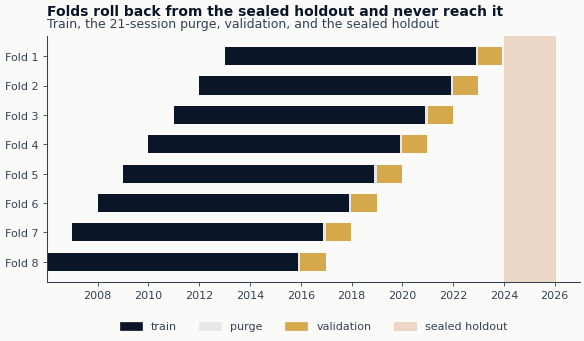

In [12]:
splits = generate_cv_splits(
    prices.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
purge_note = f"Train, the {PRIMARY_HORIZON}-session purge, validation, and the sealed holdout"
add_message_title(ax, "Folds roll back from the sealed holdout and never reach it", purge_note)
plt.show()

## E. Derived artifacts

The eligibility table is the one thing this notebook hands downstream: `02_labels` and
`03_financial_features` semi-join on it, so a fund contributes rows only in years it cleared, and
it covers the sealed years too, since prior-year volume is all the rule ever reads.

In [13]:
eligibility.write_csv(CASE_DIR / "eligibility.csv")
print(f"Written: eligibility.csv, {len(eligibility):,} fund-year pairs")

Written: eligibility.csv, 1,670 fund-year pairs


## F. Findings vs `setup.yaml`

One row per knob: the evidence that motivates it, and what would change it.

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.eligibility_rule` | B.2 breadth at each decision date | breadth falls under the position count the sweep asks for |
| `decision.cadence` | B.3 exceedance | moves stop clearing the round trip, or the label horizon no longer fits inside one rebalancing interval |
| `costs.asset_spreads` | B.3 cost per fund from the declared commission and half-spread | quoted spreads become available and disagree with the assigned tier |
| `evaluation.n_splits` | D.2 fold boundaries | the folds no longer fit the development window |

In [14]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, eligible per decision date "
    f"{breadth['n_eligible'].min()} to {breadth['n_eligible'].max()}, under the floor on "
    f"{breadth.filter(pl.col('n_eligible') < BREADTH_FLOOR).height} of {len(breadth)} dates\n"
    f"decision.cadence {SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 100, eligible per decision date 0 to 96, under the floor on 12 of 216 dates
decision.cadence monthly_month_end | labels.primary fwd_ret_21d
evaluation.n_splits 8, generated 8, last validation ends 2023-11-29, holdout untouched


Eligible breadth runs from 0 in the first year, before any fund has a prior year to be admitted on,
to 96 of the declared 100, and sits under the position floor on 12 of 216 decision dates, every one
of them in that first year. Eight folds are generated, the last validation ending 2023-11-29.

## Key takeaways

1. **Decide membership on prior-year information, and count it on the decision date.** A liquidity
   filter fitted to the whole sample keeps the funds that stayed liquid.
2. **Convert a per-share cost into bps before comparing it to a return**, and scale each move by
   its own fund's round trip: a cent of spread is a different cost on a low-priced fund.
3. **Compute a panel autocorrelation inside each entity**, never across the stacked panel.

### Known limitations

- The funds in `universe.assets` were chosen knowing which of them still trade, so the
  point-in-time filter removes a bias inside the list and not the bias in the list itself.
- `close` is adjusted for splits and distributions, so early prices sit below what a fund traded
  at: dollar volume is understated there, and the round trip, being dollars per share over a
  price, is overstated. The half-spread is by tier, and the floor is not inflation-adjusted.
- Eligibility is annual while decisions are monthly, so a fund turning illiquid in March keeps its
  place until January.

**Next**: labels at the declared horizons, built on this development window.